# FiftyOne Dataset Analysis for Prostate Cancer Grading

This notebook uses FiftyOne to explore, visualize, and analyze the histopathology dataset.

## What is FiftyOne?

FiftyOne is an open-source toolkit for dataset curation, model evaluation, and visualization.

### Key Features:
- Interactive dataset visualization in browser
- Advanced filtering and querying
- Model evaluation and error analysis
- Embeddings visualization (t-SNE, UMAP)
- Label quality assessment
- Dataset versioning and annotation

### Installation:
```bash
pip install fiftyone
```

## 1. Setup and Imports

In [11]:
import fiftyone as fo
import fiftyone.brain as fob
import fiftyone.zoo as foz
import pandas as pd
import numpy as np
import os
from pathlib import Path
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

print(f"FiftyOne version: {fo.__version__}")
print(f"PyTorch version: {torch.__version__}")

FiftyOne version: 1.8.1
PyTorch version: 2.8.0+cu128


## 2. Configuration

In [12]:
# Paths
ROOT_DIR = '..'
data_dir = '../../dataset'
images_dir = os.path.join(data_dir, 'tiles')

# Dataset files
train_csv = f"{ROOT_DIR}/data/train_5fold.csv"
test_csv = f"{ROOT_DIR}/data/test.csv"

# FiftyOne dataset name
dataset_name = "prostate-cancer-grading"

# Class names
class_names = {
    0: "ISUP 0 (No cancer)",
    1: "ISUP 1 (3+3)",
    2: "ISUP 2 (3+4)",
    3: "ISUP 3 (4+3)",
    4: "ISUP 4 (4+4, 3+5, 5+3)",
    5: "ISUP 5 (4+5, 5+4, 5+5)"
}

print(f"Images directory: {images_dir}")
print(f"Dataset exists: {os.path.exists(images_dir)}")

Images directory: ../../dataset/tiles
Dataset exists: True


## 3. Load Data into FiftyOne

In [13]:
def create_fiftyone_dataset(csv_path, images_dir, split_name, dataset_name="prostate-cancer"):
    """
    Create a FiftyOne dataset from CSV and images.
    
    Args:
        csv_path: Path to CSV with annotations
        images_dir: Directory containing images
        split_name: Name of the split (train/test)
        dataset_name: Name for the FiftyOne dataset
    """
    # Load CSV
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    
    print(f"Creating FiftyOne dataset for {split_name}")
    print(f"  Total samples: {len(df)}")
    
    # Create samples
    samples = []
    missing_images = []
    
    for idx, row in df.iterrows():
        image_id = row['image_id'].strip()
        image_path = os.path.join(images_dir, f"{image_id}.jpg")
        
        # Check if image exists
        if not os.path.exists(image_path):
            missing_images.append(image_id)
            continue
        
        # Create sample
        sample = fo.Sample(filepath=image_path)
        
        # Add metadata
        sample["image_id"] = image_id
        sample["split"] = split_name
        sample["data_provider"] = row.get('data_provider', 'unknown')
        sample["isup_grade"] = int(row['isup_grade'])
        sample["gleason_score"] = row['gleason_score']
        
        # Add fold if available
        if 'fold' in row:
            sample["fold"] = int(row['fold'])
        
        # Add classification label
        sample["ground_truth"] = fo.Classification(
            label=class_names[int(row['isup_grade'])],
            confidence=1.0
        )
        
        samples.append(sample)
        
        if (idx + 1) % 1000 == 0:
            print(f"  Processed {idx + 1}/{len(df)} samples")
    
    if missing_images:
        print(f"  Warning: {len(missing_images)} images not found")
    
    print(f"  Successfully loaded {len(samples)} samples")
    
    return samples

# Delete existing dataset if it exists
if dataset_name in fo.list_datasets():
    print(f"Deleting existing dataset: {dataset_name}")
    fo.delete_dataset(dataset_name)

# Create new dataset
dataset = fo.Dataset(dataset_name)
dataset.persistent = True  # Save to disk

print("Loading training data...")
train_samples = create_fiftyone_dataset(train_csv, images_dir, "train", dataset_name)
dataset.add_samples(train_samples)

print("\nLoading test data...")
test_samples = create_fiftyone_dataset(test_csv, images_dir, "test", dataset_name)
dataset.add_samples(test_samples)

print(f"\nDataset '{dataset_name}' created successfully!")
print(f"Total samples: {len(dataset)}")
print(dataset)

Deleting existing dataset: prostate-cancer-grading
Loading training data...
Creating FiftyOne dataset for train
  Total samples: 9024
  Processed 1000/9024 samples
  Processed 2000/9024 samples
  Processed 3000/9024 samples
  Processed 4000/9024 samples
  Processed 5000/9024 samples
  Processed 6000/9024 samples
  Processed 7000/9024 samples
  Processed 8000/9024 samples
  Processed 9000/9024 samples
  Successfully loaded 9024 samples

Loading test data...
Creating FiftyOne dataset for test
  Total samples: 1592
  Processed 1000/1592 samples
  Successfully loaded 1592 samples

Dataset 'prostate-cancer-grading' created successfully!
Total samples: 10616
Name:        prostate-cancer-grading
Media type:  image
Num samples: 10616
Persistent:  True
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:   

## 4. Dataset Statistics and Exploration

In [14]:
# Basic statistics
print("Dataset Statistics:")
print(f"  Total samples: {len(dataset)}")
print(f"  Train samples: {len(dataset.match_tags('train')) if 'train' in dataset.distinct('split') else len(dataset.match({'split': 'train'}))}")
print(f"  Test samples: {len(dataset.match({'split': 'test'}))}")

# Class distribution
print("\nClass Distribution:")
for grade in range(6):
    count = len(dataset.match({"isup_grade": grade}))
    percentage = count / len(dataset) * 100
    print(f"  {class_names[grade]}: {count} ({percentage:.2f}%)")

# Data provider distribution
print("\nData Provider Distribution:")
providers = dataset.distinct("data_provider")
for provider in providers:
    count = len(dataset.match({"data_provider": provider}))
    percentage = count / len(dataset) * 100
    print(f"  {provider}: {count} ({percentage:.2f}%)")

Dataset Statistics:
  Total samples: 10616
  Train samples: 0
  Test samples: 1592

Class Distribution:
  ISUP 0 (No cancer): 2892 (27.24%)
  ISUP 1 (3+3): 2666 (25.11%)
  ISUP 2 (3+4): 1343 (12.65%)
  ISUP 3 (4+3): 1242 (11.70%)
  ISUP 4 (4+4, 3+5, 5+3): 1249 (11.77%)
  ISUP 5 (4+5, 5+4, 5+5): 1224 (11.53%)

Data Provider Distribution:
  karolinska: 5456 (51.39%)
  radboud: 5160 (48.61%)


## 5. Launch FiftyOne App

This opens an interactive browser interface for exploring the dataset.

In [15]:
# Launch the FiftyOne App
session = fo.launch_app(dataset, port=5151)

print("\nFiftyOne App launched!")
print("Open your browser and navigate to: http://localhost:5151")
print("\nUseful tips:")
print("  - Click on images to view in detail")
print("  - Use the sidebar to filter by grade, provider, etc.")
print("  - Use the search bar for advanced queries")
print("  - Right-click for tagging and operations")


FiftyOne App launched!
Open your browser and navigate to: http://localhost:5151

Useful tips:
  - Click on images to view in detail
  - Use the sidebar to filter by grade, provider, etc.
  - Use the search bar for advanced queries
  - Right-click for tagging and operations


## 6. Advanced Filtering Examples

In [16]:
# Example 1: Filter by ISUP grade
high_grade = dataset.match({"isup_grade": {"$gte": 4}})
print(f"High-grade samples (ISUP 4-5): {len(high_grade)}")

# Example 2: Filter by data provider
radboud = dataset.match({"data_provider": "radboud"})
print(f"Radboud samples: {len(radboud)}")

# Example 3: Filter by Gleason score
gleason_4_4 = dataset.match({"gleason_score": "4+4"})
print(f"Gleason 4+4 samples: {len(gleason_4_4)}")

# Example 4: Filter training set only
train_data = dataset.match({"split": "train"})
print(f"Training samples: {len(train_data)}")

# Example 5: Combine filters (high-grade training samples from Radboud)
filtered = dataset.match({
    "isup_grade": {"$gte": 4},
    "split": "train",
    "data_provider": "radboud"
})
print(f"High-grade training samples from Radboud: {len(filtered)}")

High-grade samples (ISUP 4-5): 2473
Radboud samples: 5160
Gleason 4+4 samples: 1126
Training samples: 9024
High-grade training samples from Radboud: 1473


## 7. Visualize Class Distribution

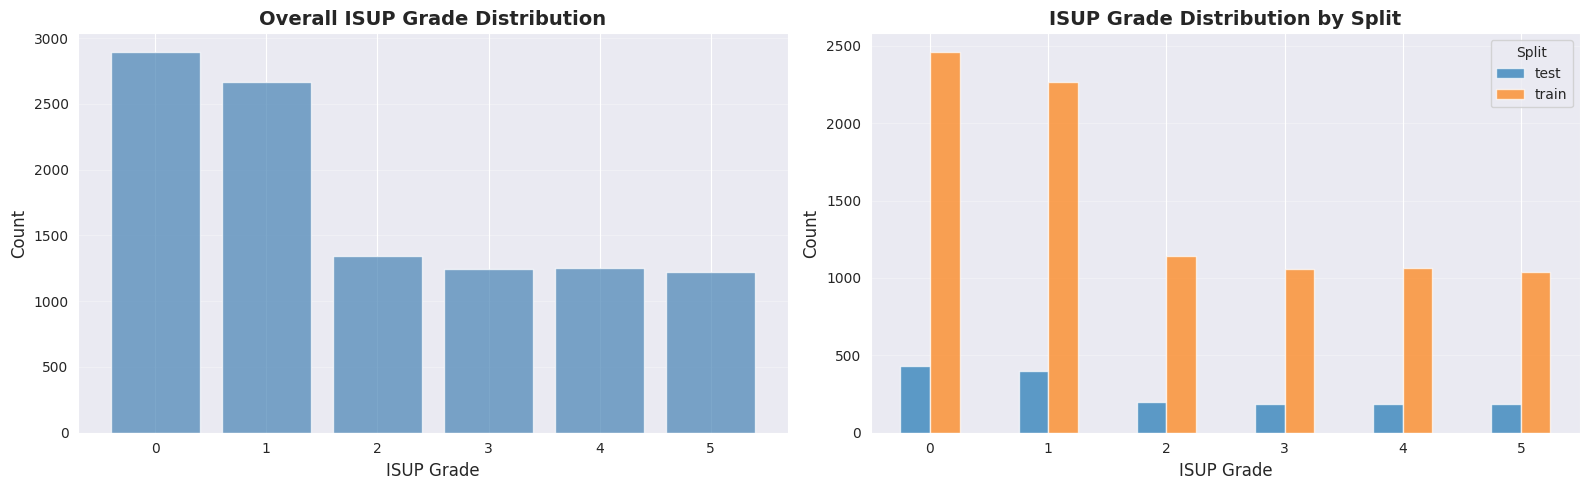

Class distribution plot saved to visualizations/fiftyone_class_distribution.png


In [17]:
# Extract class distribution
grades = []
splits = []

for sample in dataset:
    grades.append(sample.isup_grade)
    splits.append(sample.split)

df_viz = pd.DataFrame({'grade': grades, 'split': splits})

# Plot class distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Overall distribution
grade_counts = df_viz['grade'].value_counts().sort_index()
axes[0].bar(grade_counts.index, grade_counts.values, color='steelblue', alpha=0.7)
axes[0].set_xlabel('ISUP Grade', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Overall ISUP Grade Distribution', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(6))
axes[0].grid(alpha=0.3, axis='y')

# Distribution by split
split_counts = df_viz.groupby(['split', 'grade']).size().unstack(fill_value=0)
split_counts.T.plot(kind='bar', ax=axes[1], color=['#1f77b4', '#ff7f0e'], alpha=0.7)
axes[1].set_xlabel('ISUP Grade', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('ISUP Grade Distribution by Split', fontsize=14, fontweight='bold')
axes[1].legend(title='Split', fontsize=10)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('visualizations/fiftyone_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Class distribution plot saved to visualizations/fiftyone_class_distribution.png")

## 8. Compute Embeddings with Pre-trained Model

We'll use EfficientNet-B0 to extract feature embeddings for similarity analysis.

In [18]:
from torchvision import transforms
from tqdm import tqdm

# Load pre-trained EfficientNet
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
model.classifier = nn.Identity()  # Remove classifier, keep features only
model = model.to(device)
model.eval()

print(f"Model loaded on {device}")

# Image preprocessing
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def compute_embeddings(dataset, model, device, batch_size=32):
    """
    Compute embeddings for all samples in the dataset.
    """
    embeddings = []
    sample_ids = []
    
    print("Computing embeddings...")
    
    with torch.no_grad():
        batch_images = []
        batch_ids = []
        
        for sample in tqdm(dataset, desc="Processing images"):
            # Load and preprocess image
            img = Image.open(sample.filepath).convert('RGB')
            img_tensor = preprocess(img)
            
            batch_images.append(img_tensor)
            batch_ids.append(sample.id)
            
            # Process batch
            if len(batch_images) == batch_size:
                batch_tensor = torch.stack(batch_images).to(device)
                features = model(batch_tensor)
                embeddings.extend(features.cpu().numpy())
                sample_ids.extend(batch_ids)
                
                batch_images = []
                batch_ids = []
        
        # Process remaining samples
        if batch_images:
            batch_tensor = torch.stack(batch_images).to(device)
            features = model(batch_tensor)
            embeddings.extend(features.cpu().numpy())
            sample_ids.extend(batch_ids)
    
    embeddings = np.array(embeddings)
    print(f"Computed {len(embeddings)} embeddings with shape {embeddings.shape}")
    
    return embeddings, sample_ids

# Compute embeddings (this may take a few minutes)
embeddings, sample_ids = compute_embeddings(dataset, model, device, batch_size=32)

# Store embeddings in dataset
print("Storing embeddings in dataset...")
for idx, sample_id in enumerate(tqdm(sample_ids, desc="Saving embeddings")):
    sample = dataset[sample_id]
    sample["embedding"] = embeddings[idx]
    sample.save()

print("Embeddings computed and saved!")

/home/woshington/Projects/Doutorado/repo/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:182: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


Model loaded on cpu
Computing embeddings...


Processing images:  11%|█         | 1140/10616 [01:50<15:21, 10.29it/s] 

KeyboardInterrupt



## 9. Visualize Embeddings with UMAP

In [ ]:
# Compute UMAP visualization
print("Computing UMAP visualization...")
results = fob.compute_visualization(
    dataset,
    embeddings="embedding",
    brain_key="umap_visualization",
    method="umap",
    num_dims=2,
    seed=42
)

print("UMAP visualization computed!")
print("You can now view the embedding space in the FiftyOne App:")
print("  1. Click on the 'Embeddings' tab in the App")
print("  2. Select 'umap_visualization' from the dropdown")
print("  3. Color by 'isup_grade' to see class clusters")

# Refresh session to see embeddings
session.view = dataset

## 10. Find Similar Images

Use embeddings to find visually similar samples.

In [ ]:
# Build similarity index
print("Building similarity index...")
fob.compute_similarity(
    dataset,
    embeddings="embedding",
    brain_key="similarity_index",
)

print("Similarity index built!")
print("\nTo find similar images in the App:")
print("  1. Select a sample in the grid")
print("  2. Right-click and choose 'Find similar'")
print("  3. The most similar images will be shown")

# Example: Find similar images programmatically
# Get a random sample
sample = dataset.first()
print(f"\nFinding images similar to: {sample.image_id}")
print(f"  ISUP Grade: {sample.isup_grade}")
print(f"  Gleason Score: {sample.gleason_score}")

# Query for similar images
similar_view = dataset.sort_by_similarity(
    sample.id,
    brain_key="similarity_index",
    k=10  # Top 10 most similar
)

print(f"\nTop 10 most similar images:")
for idx, s in enumerate(similar_view.limit(10)):
    print(f"  {idx+1}. {s.image_id} - ISUP {s.isup_grade} ({s.gleason_score})")

# Update session to show similar images
session.view = similar_view

## 11. Identify Hard/Confusing Samples

Find samples that are close to decision boundaries in embedding space.

In [ ]:
# Compute uniqueness scores (samples far from others are "unique")
print("Computing uniqueness scores...")
fob.compute_uniqueness(
    dataset,
    embeddings="embedding",
    uniqueness_field="uniqueness",
)

# Find most unique samples (potential outliers or hard cases)
unique_samples = dataset.sort_by("uniqueness", reverse=True).limit(20)

print("\nMost unique/unusual samples:")
for idx, sample in enumerate(unique_samples):
    print(f"  {idx+1}. {sample.image_id} - ISUP {sample.isup_grade} (uniqueness: {sample.uniqueness:.4f})")

# View in app
session.view = unique_samples

print("\nThese samples might be:")
print("  - Unusual tissue patterns")
print("  - Potential labeling errors")
print("  - Rare but valid cases")
print("  - Difficult samples near class boundaries")

## 12. Add Model Predictions (Optional)

If you have a trained model, you can add predictions to the dataset.

In [ ]:
# Example: Load a trained model and add predictions
# This is optional - uncomment if you want to evaluate a model

"""
# Load your trained model
from utils.models import EfficientNetApi

trained_model = efficientnet_b0(weights=None)
trained_model = EfficientNetApi(model=trained_model, output_dimensions=5, dropout_rate=0.6)
trained_model.load_state_dict(torch.load('../code/tests/models/efficientnet-b0.pth'))
trained_model = trained_model.to(device)
trained_model.eval()

# Add predictions to dataset
print("Adding model predictions...")

with torch.no_grad():
    for sample in tqdm(dataset, desc="Making predictions"):
        # Load and preprocess image
        img = Image.open(sample.filepath).convert('RGB')
        img_tensor = preprocess(img).unsqueeze(0).to(device)
        
        # Get prediction
        output = trained_model(img_tensor)
        probs = torch.sigmoid(output)
        pred_grade = int(probs.sum(1).round().item())
        confidence = probs.max().item()
        
        # Store prediction
        sample["prediction"] = fo.Classification(
            label=class_names[pred_grade],
            confidence=confidence,
            logits=output[0].cpu().numpy().tolist()
        )
        sample["pred_grade"] = pred_grade
        sample["correct"] = (pred_grade == sample.isup_grade)
        sample.save()

print("Predictions added!")

# Evaluate model
results = dataset.evaluate_classifications(
    "prediction",
    gt_field="ground_truth",
    eval_key="eval",
)

print("\nModel Evaluation:")
print(results.metrics())

# Find misclassified samples
errors = dataset.match({"correct": False})
print(f"\nMisclassified samples: {len(errors)}")

session.view = errors
"""

print("To add predictions, uncomment and run the code above")

## 13. Export Filtered Dataset

In [ ]:
# Example: Export high-grade samples to a new CSV
high_grade_view = dataset.match({"isup_grade": {"$gte": 4}})

# Extract data
export_data = []
for sample in high_grade_view:
    export_data.append({
        'image_id': sample.image_id,
        'isup_grade': sample.isup_grade,
        'gleason_score': sample.gleason_score,
        'data_provider': sample.data_provider,
        'split': sample.split,
    })

df_export = pd.DataFrame(export_data)
df_export.to_csv('visualizations/high_grade_samples.csv', index=False)

print(f"Exported {len(df_export)} high-grade samples to visualizations/high_grade_samples.csv")

## 14. Summary and Tips

In [ ]:
print("="*70)
print("FiftyOne Dataset Analysis Summary")
print("="*70)

print(f"\nDataset: {dataset.name}")
print(f"Total samples: {len(dataset)}")
print(f"Persistent: {dataset.persistent}")

print("\nFeatures added:")
print("  ✓ Image metadata (grade, Gleason score, provider)")
print("  ✓ EfficientNet embeddings (1280-dim)")
print("  ✓ UMAP visualization (2D projection)")
print("  ✓ Similarity index for finding similar images")
print("  ✓ Uniqueness scores for identifying outliers")

print("\nUseful FiftyOne App features:")
print("  - Embeddings tab: Visualize clusters in 2D space")
print("  - Filters: Filter by grade, provider, split, etc.")
print("  - Similarity: Right-click → Find similar images")
print("  - Tagging: Mark interesting samples for later review")
print("  - Export: Export filtered subsets")

print("\nNext steps:")
print("  1. Explore the interactive App at http://localhost:5151")
print("  2. Investigate unique/outlier samples")
print("  3. Find visually similar images across grades")
print("  4. Add model predictions for error analysis")
print("  5. Use insights to improve data quality and model")

print("\n" + "="*70)
print("Keep the session running to use the FiftyOne App!")
print("Run session.wait() to keep the notebook alive.")
print("="*70)

In [ ]:
# Keep session alive (optional - run this cell to prevent notebook from closing)
# session.wait()